# Numerical Differentiation & Integration



## Differentiation Algorithms

* The goal: given the function $f (x)$ explicitly or implicitly, compute $\large \frac{d^nf}{dx^n}$ **numerically** at given x.
* In mathematics, function derivatives are often used to model the changes. 
* However, in practice the function may not be explicitly known, or the function may be implicitly represented by a set of data points. 
* In these cases and others, it may be desirable to compute derivatives numerically rather than analytically.
* So we need numerical differentiation.

## Numerical Differentiation Problem Statement and Annotations

* A **numerical grid** is an evenly spaced set of points over the domain of a function (i.e., the independent variable), over some interval. 
* The **spacing** or **step size** of a numerical grid is the distance between adjacent points on the grid. 

### For example

In this class, if $x$ is a numerical grid, then $x_j$ is the $j^{\mathrm{th}}$ point in the numerical grid and $h$ is the spacing between $x_{j-1}$ and $x_j$. 

The following figure shows an example of a numerical grid.

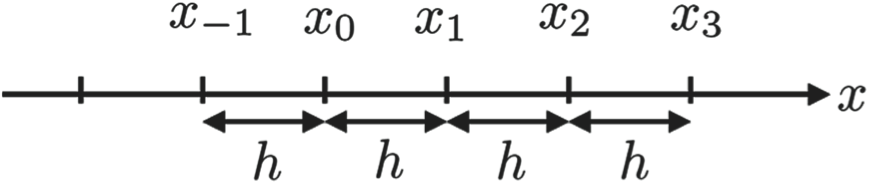



### Numerical grid in Python

* For numerical grids in one dimension, it is sufficient to use the `linspace` function.

* In Python, a function $f(x)$ can be represented over an interval by computing its value on a grid. 

In [1]:
import numpy as np
np.linspace(1, 10)

array([ 1.        ,  1.18367347,  1.36734694,  1.55102041,  1.73469388,
        1.91836735,  2.10204082,  2.28571429,  2.46938776,  2.65306122,
        2.83673469,  3.02040816,  3.20408163,  3.3877551 ,  3.57142857,
        3.75510204,  3.93877551,  4.12244898,  4.30612245,  4.48979592,
        4.67346939,  4.85714286,  5.04081633,  5.2244898 ,  5.40816327,
        5.59183673,  5.7755102 ,  5.95918367,  6.14285714,  6.32653061,
        6.51020408,  6.69387755,  6.87755102,  7.06122449,  7.24489796,
        7.42857143,  7.6122449 ,  7.79591837,  7.97959184,  8.16326531,
        8.34693878,  8.53061224,  8.71428571,  8.89795918,  9.08163265,
        9.26530612,  9.44897959,  9.63265306,  9.81632653, 10.        ])

In [2]:
len(np.linspace(1, 10))

50

In [3]:
np.linspace(1, 10, num=100)

array([ 1.        ,  1.09090909,  1.18181818,  1.27272727,  1.36363636,
        1.45454545,  1.54545455,  1.63636364,  1.72727273,  1.81818182,
        1.90909091,  2.        ,  2.09090909,  2.18181818,  2.27272727,
        2.36363636,  2.45454545,  2.54545455,  2.63636364,  2.72727273,
        2.81818182,  2.90909091,  3.        ,  3.09090909,  3.18181818,
        3.27272727,  3.36363636,  3.45454545,  3.54545455,  3.63636364,
        3.72727273,  3.81818182,  3.90909091,  4.        ,  4.09090909,
        4.18181818,  4.27272727,  4.36363636,  4.45454545,  4.54545455,
        4.63636364,  4.72727273,  4.81818182,  4.90909091,  5.        ,
        5.09090909,  5.18181818,  5.27272727,  5.36363636,  5.45454545,
        5.54545455,  5.63636364,  5.72727273,  5.81818182,  5.90909091,
        6.        ,  6.09090909,  6.18181818,  6.27272727,  6.36363636,
        6.45454545,  6.54545455,  6.63636364,  6.72727273,  6.81818182,
        6.90909091,  7.        ,  7.09090909,  7.18181818,  7.27

### Discrete representation of function
* Although the function itself may be continuous, this **discrete** or **discretized** representation is useful for numerical calculations and corresponds to data sets that may be acquired in real world. 
* Specifically, the function value may only be known at discrete points. 


### For example

* A temperature sensor may deliver temperature versus time pairs at regular time intervals. 
* Although temperature is a smooth and continuous function of time, the sensor only provides values at discrete time intervals
* In this case, the underlying function would not even be known.


## The goal

* Whether $f$ is an analytic function or a discrete representation of one, we would like to derive methods of approximating the derivative of $f$ over a numerical grid and determine their accuracy.



## Finite Difference Approximating Derivatives

### The definition of derivative

The derivative $f'(x)$ of a function $f(x)$ at the point $x=a$ is defined as:

$$\large f'(a) = \lim\limits_{x \to a}\frac{f(x) - f(a)}{x-a}$$

The derivative at $x=a$ is the slope at this point. 

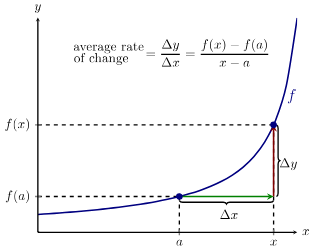

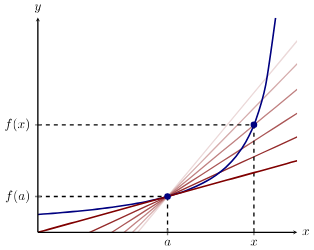

### Finite Difference Method

In **finite difference** approximations of this slope, we can use values of the function in the neighborhood of the point $x=a$ to achieve the goal.


1. The **forward difference** (aka, in industry, we call it "single-sided method") is to estimate the slope of the function at $x_j$ using the line that connects $(x_j, f(x_j))$ and $(x_{j+1}, f(x_{j+1}))$:

$$\large f'(x_j) = \frac{f(x_{j+1}) - f(x_j)}{x_{j+1}-x_j}$$

2. The **backward difference** (aka, still "single-sided method") is to estimate the slope of the function at $x_j$ using the line that connects $(x_{j-1}, f(x_{j-1}))$ and $(x_j, f(x_j))$:

$$\large f'(x_j) = \frac{f(x_j) - f(x_{j-1})}{x_j - x_{j-1}}$$

3. The **central difference** (aka, in industry, we call it "double-sided method") is to estimate the slope of the function at $x_j$ using the line that connects $(x_{j-1}, f(x_{j-1}))$ and $(x_{j+1}, f(x_{j+1}))$:

$$\large f'(x_j) = \frac{f(x_{j+1}) - f(x_{j-1})}{x_{j+1} - x_{j-1}}$$

The following figure illustrates the three different type of formulas to estimate the slope. 

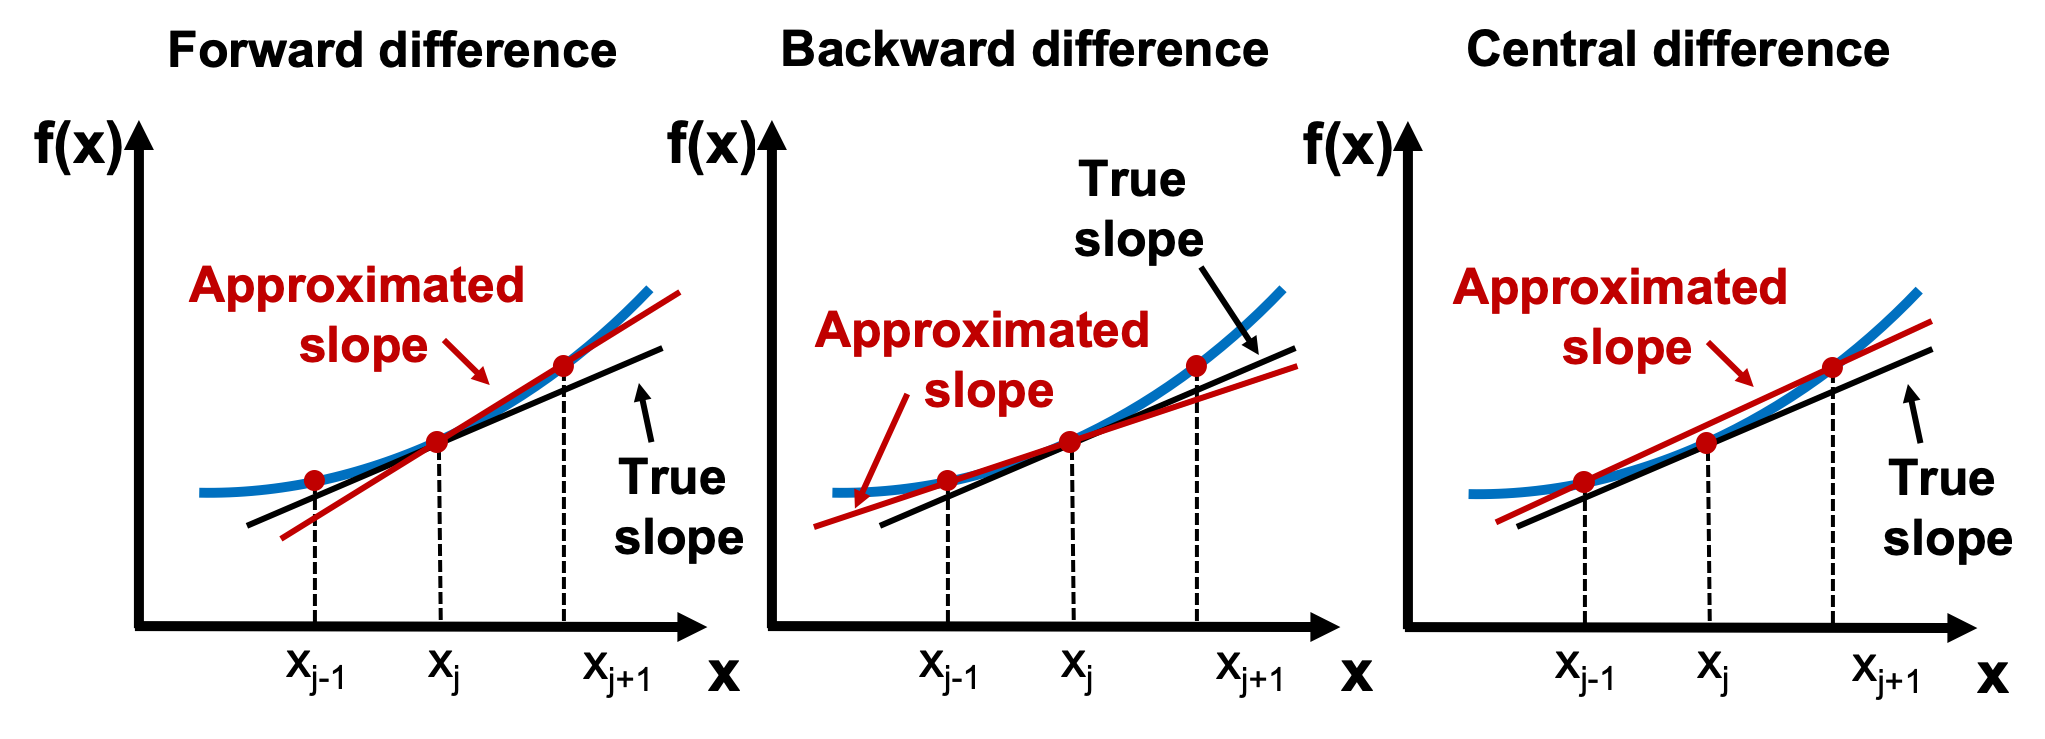

## Finite Difference Approximating Derivatives with Taylor Series & Accuracy

To derive an approximation for the derivative of $f$, we return to Taylor series. For an arbitrary function $f(x)$ the Taylor series of $f$ around $a = x_j$ is


$$\large
f(x) = \frac{f(x_j)(x - x_j)^0}{0!} + \frac{f^{\prime}(x_j)(x - x_j)^1}{1!} + \frac{f''(x_j)(x - x_j)^2}{2!} + \frac{f'''(x_j)(x - x_j)^3}{3!} + \cdots.
$$


If $x$ is on a grid of points with spacing $h$, we can compute the Taylor series at $x = x_{j+1}$ to get


$$\large
f(x_{j+1}) = \frac{f(x_j)(x_{j+1} - x_j)^0}{0!} + \frac{f^{\prime}(x_j)(x_{j+1}- x_j)^1}{1!} + \frac{f''(x_j)(x_{j+1} - x_j)^2}{2!} + \frac{f'''(x_j)(x_{j+1} - x_j)^3}{3!} + \cdots.
$$


Substituting $h = x_{j+1} - x_j$ and solving for $f^{\prime}(x_j)$ gives the equation


$$\large
f^{\prime}(x_j) = \frac{f(x_{j+1}) - f(x_j)}{h} + \left(-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots\right).
$$


The terms that are in parentheses, $-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots$, are called **higher order terms** of $h$. The higher order terms can be rewritten as


$$\large
-\frac{f''(x_j)h}{2!} -\frac{f'''(x_j)h^2}{3!} - \cdots = h(\alpha + \epsilon(h)),
$$


where $\alpha$ is some constant, and $\epsilon(h)$ is a function of $h$ that goes to zero as $h$ goes to 0. We use the abbreviation "$O(h)$" for $h(\alpha + \epsilon(h))$, and in general, we use the abbreviation "$O(h^p)$" to denote $h^p(\alpha + \epsilon(h))$.


Substituting $O(h)$ into the previous equations gives


$$\large
f^{\prime}(x_j) = \frac{f(x_{j+1}) - f(x_j)}{h} + O(h).
$$


This gives the **forward difference** formula for approximating derivatives as


$$\large
f^{\prime}(x_j) \approx \frac{f(x_{j+1}) - f(x_j)}{h},
$$


and we say this formula is $O(h)$.

### Accuracy

* $O(h)$ describes the **accuracy** of the forward difference formula for approximating derivatives. 

* For an approximation that is $O(h^p)$, we say that $p$ is the **order** of the accuracy of the approximation. 

* With few exceptions, higher order accuracy is better than lower order. 
    - assume $q < p$. Then as the spacing, $h > 0$, goes to 0, $h^p$ goes to 0 faster than $h^q$. Therefore as $h$ goes to 0, an approximation of a value that is $O(h^p)$ gets closer to the true value faster than one that is $O(h^q)$.

By computing the Taylor series around $a = x_j$ at $x = x_{j-1}$ and again solving for $f^{\prime}(x_j)$, we get the **backward difference** formula

$$\large
f^{\prime}(x_j) \approx \frac{f(x_j) - f(x_{j-1})}{h},
$$

which is also $O(h)$. 

### Central difference is more accurate

* Intuitively, the forward and backward difference formulas for the derivative at $x_j$ are just the slopes between the point at $x_j$ and the points $x_{j+1}$ and $x_{j-1}$, respectively.

* Neither of them is accurate. One is slightly bigger and the other is slightly smaller. 

* The average of them will be more accurate. Here is why,

Compute the Taylor series around $a = x_j$ at both $x_{j+1}$ and $x_{j-1}$. Written out, these equations are

$$\large
f(x_{j+1}) = f(x_j) + f^{\prime}(x_j)h + \frac{1}{2}f''(x_j)h^2 + \frac{1}{6}f'''(x_j)h^3 + \cdots
$$

and

$$\large
f(x_{j-1}) = f(x_j) - f^{\prime}(x_j)h + \frac{1}{2}f''(x_j)h^2 - \frac{1}{6}f'''(x_j)h^3 + \cdots.
$$

Subtracting the formulas above gives

$$\large
f(x_{j+1}) - f(x_{j-1}) = 2f^{\prime}(x_j)h + \frac{1}{3}f'''(x_j)h^3 + \cdots,
$$
which when solved for $f^{\prime}(x_j)$ gives the **central difference** formula

$$\large
f^{\prime}(x_j) \approx \frac{f(x_{j+1}) - f(x_{j-1})}{2h}.
$$

* The central difference formula is $O(h^2)$, even though it requires the same amount of computational effort as the forward and backward difference formulas!
* In general, formulas that utilize symmetric points around $x_j$, for example $x_{j-1}$ and $x_{j+1}$, have better accuracy than asymmetric ones, such as the forward and background difference formulas.

* The following figure shows the forward difference (line joining $(x_j, y_j)$ and $(x_{j+1}, y_{j+1})$), backward difference (line joining $(x_j, y_j)$ and $(x_{j-1}, y_{j-1})$), and central difference (line joining $(x_{j-1}, y_{j-1})$ and $(x_{j+1}, y_{j+1})$) approximation of the derivative of a function $f$. 

* The difference in the value of the slope can be significantly different based on the size of the step $h$ and the nature of the function.

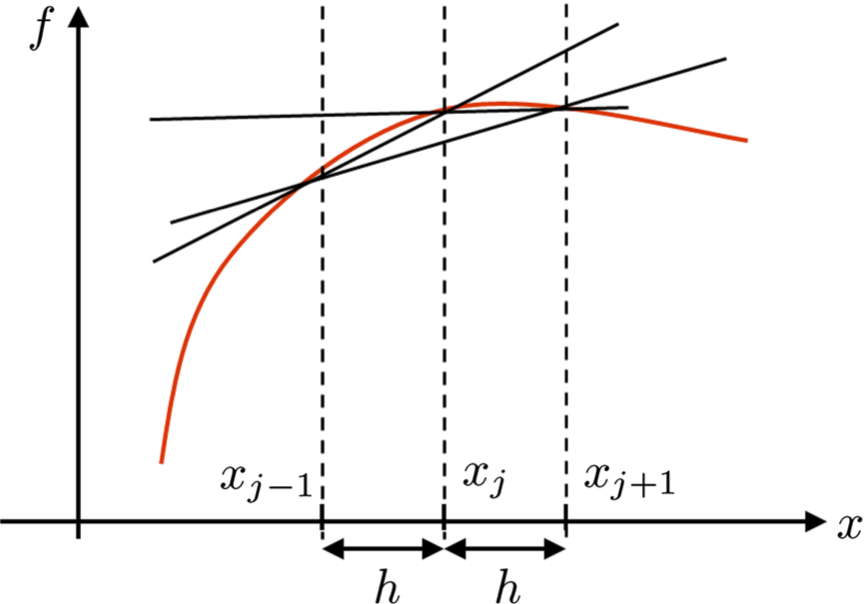


## Can we push this idea further?

Take the Taylor series of $f$ around $a = x_j$ and compute the series at $x = x_{j-2}, x_{j-1}, x_{j+1}, x_{j+2}$. Show that the resulting equations can be combined to form an approximation for $f^{\prime}(x_j)$ that is $O(h^4)$.

First, compute the Taylor series at the specified points.

$$\large
\begin{eqnarray*}
f(x_{j-2}) &=& f(x_j) - 2hf^{\prime}(x_j) + \frac{4h^2f''(x_j)}{2} - \frac{8h^3f'''(x_j)}{6} + \frac{16h^4f''''(x_j)}{24} - \frac{32h^5f'''''(x_j)}{120} + \cdots\\
f(x_{j-1}) &=& f(x_j) - hf^{\prime}(x_j) + \frac{h^2f''(x_j)}{2} - \frac{h^3f'''(x_j)}{6} + \frac{h^4f''''(x_j)}{24} - \frac{h^5f'''''(x_j)}{120} + \cdots\\
f(x_{j+1}) &=& f(x_j) + hf^{\prime}(x_j) + \frac{h^2f''(x_j)}{2} + \frac{h^3f'''(x_j)}{6} + \frac{h^4f''''(x_j)}{24} + \frac{h^5f'''''(x_j)}{120} + \cdots\\
f(x_{j+2}) &=& f(x_j) + 2hf^{\prime}(x_j) + \frac{4h^2f''(x_j)}{2} + \frac{8h^3f'''(x_j)}{6} + \frac{16h^4f''''(x_j)}{24} + \frac{32h^5f'''''(x_j)}{120} + \cdots
\end{eqnarray*}
$$

To get the $h^2, h^3$, and $h^4$ terms to cancel out, we can compute

$$\large f(x_{j-2}) - 8f(x_{j-1}) + 8f(x_{j+1}) - f(x_{j+2}) = 12hf^{\prime}(x_j) - \frac{48h^5f'''''(x_j)}{120}$$
which can be rearranged to

$$\large f^{\prime}(x_j) = \frac{f(x_{j-2}) - 8f(x_{j-1}) + 8f(x_{j+1}) - f(x_{j+2})}{12h} + O(h^4).$$

### It is more accurate but not worth it

This formula is a better approximation for the derivative at $x_j$ than the central difference formula, but requires twice as many calculations.

## Finite Difference in Python

* Python has a command that can be used to compute finite differences directly
* for a vector `f`, the command `d=np.diff(f)` produces an array `d` in which the entries are the differences of the adjacent elements in the initial array $f$. In other words $d(i) = f(i+1) - f(i)$.

**WARNING!** When using the command `np.diff`, the size of the output is one less than the size of the input since it needs two arguments to produce a difference.

**EXAMPLE:** 

Consider the function $f(x) = \cos(x)$. We know the derivative of $\cos(x)$ is $-\sin(x)$. The following code computes the derivatives numerically.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
# step size
h = 0.1
# define grid
x = np.arange(0, 2*np.pi, h) 
# compute function
y = np.cos(x) 
x, y

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
        3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
        5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2]),
 array([ 1.        ,  0.99500417,  0.98006658,  0.95533649,  0.92106099,
         0.87758256,  0.82533561,  0.76484219,  0.69670671,  0.62160997,
         0.54030231,  0.45359612,  0.36235775,  0.26749883,  0.16996714,
         0.0707372 , -0.02919952, -0.12884449, -0.22720209, -0.32328957,
        -0.41614684, -0.5048461 , -0.58850112, -0.66627602, -0.73739372,
        -0.80114362, -0.85688875, -0.90407214, -0.94222234, -0.97095817,
        -0.9899925 , -0.99913515, -0.99829478, -0.98747977, -0.96679819,
        -0.93645669, -0.89675842, -0.84810003, -0.79096771, -0.7259323 ,
        -0.65364362, -0.57482395, -0.49026082, -0.40079917,

In [6]:
np.diff(y)

array([-0.00499583, -0.01493759, -0.02473009, -0.0342755 , -0.04347843,
       -0.05224695, -0.06049343, -0.06813548, -0.07509674, -0.08130766,
       -0.08670618, -0.09123837, -0.09485893, -0.09753169, -0.09922994,
       -0.09993672, -0.09964497, -0.0983576 , -0.09608747, -0.09285727,
       -0.08869927, -0.08365501, -0.0777749 , -0.07111769, -0.0637499 ,
       -0.05574514, -0.04718339, -0.0381502 , -0.02873582, -0.01903433,
       -0.00914265,  0.00084037,  0.01081501,  0.02068158,  0.03034151,
        0.03969827,  0.04865838,  0.05713232,  0.06503541,  0.07228868,
        0.07881967,  0.08456313,  0.08946165,  0.0934663 ,  0.09653707,
        0.09864327,  0.09976386,  0.09988765,  0.09901339,  0.09714982,
        0.09431556,  0.09053893,  0.08585766,  0.08031854,  0.0739769 ,
        0.0668961 ,  0.05914691,  0.05080673,  0.04195891,  0.03269186,
        0.02309815,  0.01327366])

In [7]:
x1=np.linspace(1, 10, num=10)
x1

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [8]:
np.diff(x1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [9]:
len(x1), len(np.diff(x1))

(10, 9)

In [10]:
0.9965421-0.98326844

0.013273659999999965

In [11]:
# compute vector of forward differences
forward_diff = np.diff(y)/h 
forward_diff

array([-0.04995835, -0.14937587, -0.24730089, -0.34275495, -0.43478432,
       -0.52246947, -0.60493428, -0.68135478, -0.75096741, -0.81307662,
       -0.86706184, -0.91238367, -0.94858926, -0.97531686, -0.99229941,
       -0.99936724, -0.99644972, -0.983576  , -0.96087472, -0.9285727 ,
       -0.88699268, -0.83655013, -0.77774904, -0.71117694, -0.637499  ,
       -0.55745138, -0.47183389, -0.38150199, -0.28735824, -0.19034331,
       -0.09142654,  0.00840374,  0.10815006,  0.20681577,  0.30341505,
        0.39698271,  0.48658385,  0.5713232 ,  0.65035408,  0.72288683,
        0.78819674,  0.84563125,  0.89461649,  0.93466302,  0.96537071,
        0.98643272,  0.99763863,  0.99887647,  0.99013386,  0.97149816,
        0.94315557,  0.90538929,  0.85857665,  0.8031854 ,  0.73976898,
        0.66896104,  0.59146906,  0.50806732,  0.41958914,  0.32691856,
        0.23098152,  0.13273659])

In [12]:
x

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2])

In [13]:
# compute corresponding grid
x_grid = x[:-1] # exclude the last one
x_grid

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1])

In [ ]:
x[:-1]

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1])

In [ ]:
# compute exact solution
exact_solution = -np.sin(x_grid) 
exact_solution

array([-0.        , -0.09983342, -0.19866933, -0.29552021, -0.38941834,
       -0.47942554, -0.56464247, -0.64421769, -0.71735609, -0.78332691,
       -0.84147098, -0.89120736, -0.93203909, -0.96355819, -0.98544973,
       -0.99749499, -0.9995736 , -0.99166481, -0.97384763, -0.94630009,
       -0.90929743, -0.86320937, -0.8084964 , -0.74570521, -0.67546318,
       -0.59847214, -0.51550137, -0.42737988, -0.33498815, -0.23924933,
       -0.14112001, -0.04158066,  0.05837414,  0.15774569,  0.2555411 ,
        0.35078323,  0.44252044,  0.52983614,  0.61185789,  0.68776616,
        0.7568025 ,  0.81827711,  0.87157577,  0.91616594,  0.95160207,
        0.97753012,  0.993691  ,  0.99992326,  0.99616461,  0.98245261,
        0.95892427,  0.92581468,  0.88345466,  0.83226744,  0.77276449,
        0.70554033,  0.63126664,  0.55068554,  0.46460218,  0.37387666,
        0.2794155 ,  0.1821625 ])

In [ ]:
# Plot solution
plt.figure(figsize = (12, 8))
plt.plot(x_diff, forward_diff, '--', \
         label = 'Finite difference approximation')
plt.plot(x_diff, exact_solution, \
         label = 'Exact solution')
plt.legend()
plt.show()

NameError: name 'x_diff' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:
# Compute max error between 
# numerical derivative and exact solution
max_error = max(abs(exact_solution - forward_diff))
print(max_error)

0.049984407218554114


### Error analysis

* The small offset between the two curves results from the numerical error in the evaluation of the numerical derivatives. 
* The maximal error between the two numerical results is of the order 0.05 and expected to decreases with the size of the discretization step



**EXAMPLE:** 

The following code computes the numerical derivative of $f(x) = \cos(x)$ using the forward difference formula for decreasing step sizes, $h$. 


It then plots the maximum error between the approximated derivative and the true derivative versus $h$ as shown in the generated figure. 

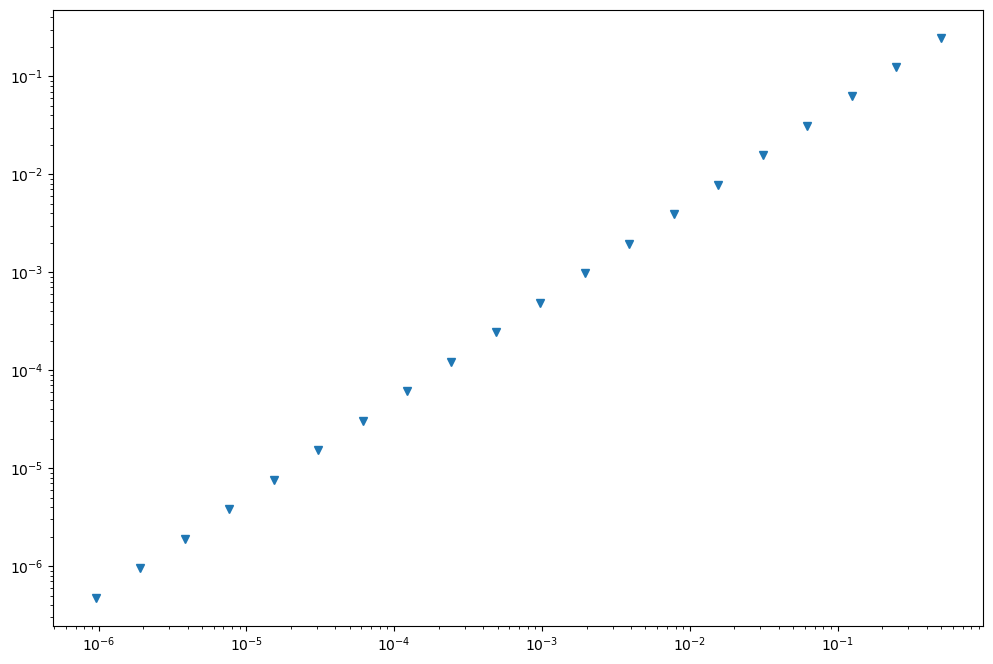

In [ ]:
# define step size
h = 1
# define number of iterations to perform
iterations = 20 
# list to store our step sizes
step_size = [] 
# list to store max error for each step size
max_error = [] 

for i in range(iterations):
    # halve the step size
    h /= 2 
    # store this step size
    step_size.append(h) 
    # compute new grid
    x = np.arange(0, 2 * np.pi, h) 
    # compute function value at grid
    y = np.cos(x) 
    # compute vector of forward differences
    forward_diff = np.diff(y)/h 
    # compute corresponding grid
    x_diff = x[:-1] 
    # compute exact solution
    exact_solution = -np.sin(x_diff) 
    
    # Compute max error between 
    # numerical derivative and exact solution
    max_error.append(\
            max(abs(exact_solution - forward_diff)))

# produce log-log plot of max error versus step size
plt.figure(figsize = (12, 8))
plt.loglog(step_size, max_error, 'v')
plt.show()

The slope of the line in log-log space is 1; therefore, the error is proportional to $h^1$, which means that, as expected, the forward difference formula is $O(h)$.

## Approximating of Higher Order Derivatives

Following the same approach, taking the Taylor series around $a = x_j$ and then computing it at $x = x_{j-1}$ and $x_{j+1}$ gives

$$\large
f(x_{j-1}) = f(x_j) - hf^{\prime}(x_j) + \frac{h^2f''(x_j)}{2} - \frac{h^3f'''(x_j)}{6} + \cdots$$

and

$$\large f(x_{j+1}) = f(x_j) + hf^{\prime}(x_j) + \frac{h^2f''(x_j)}{2} + \frac{h^3f'''(x_j)}{6} + \cdots.$$

If we add these two equations together, we get

$$\large f(x_{j-1}) + f(x_{j+1}) = 2f(x_j) + h^2f''(x_j) + \frac{h^4f''''(x_j)}{24} + \cdots,$$

and with some rearrangement gives the approximation
$$\large f''(x_j) \approx \frac{f(x_{j+1}) - 2f(x_j) + f(x_{j-1})}{h^2},$$
and is $O(h^2)$.

## Numerical Differentiation with Noise

* Sometimes data can be contaminated with **noise**, meaning its value is off by a small amount from what it would be if it were computed from a pure mathematical function. 
* This can often due to inaccuracies in measurement or the data itself can be slightly modified by perturbations outside the system of interest. For example, the real-time stock price.
* In the noisy stock market, how to estimate the trend (i.e., the derivative)?

To illustrate this point, we numerically compute the derivative of a simple cosine wave corrupted by a small sin wave. Consider the following two functions:


$$\large f(x) = \cos(x)$$

and


$$\large f_{\epsilon,\omega}(x) = \cos(x)+\epsilon \sin(\omega x)$$


where $0 < \epsilon\ll1$ is a very small number and $\omega$ is a large number. When $\epsilon$ is small, it is clear that $f\simeq f_{\epsilon,\omega}$. To illustrate this point, we plot $f_{\epsilon,\omega}(x)$ for $\epsilon = 0.01$ and $\omega = 100$, and we can see it is very close to $f(x)$, as shown in the following figure.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

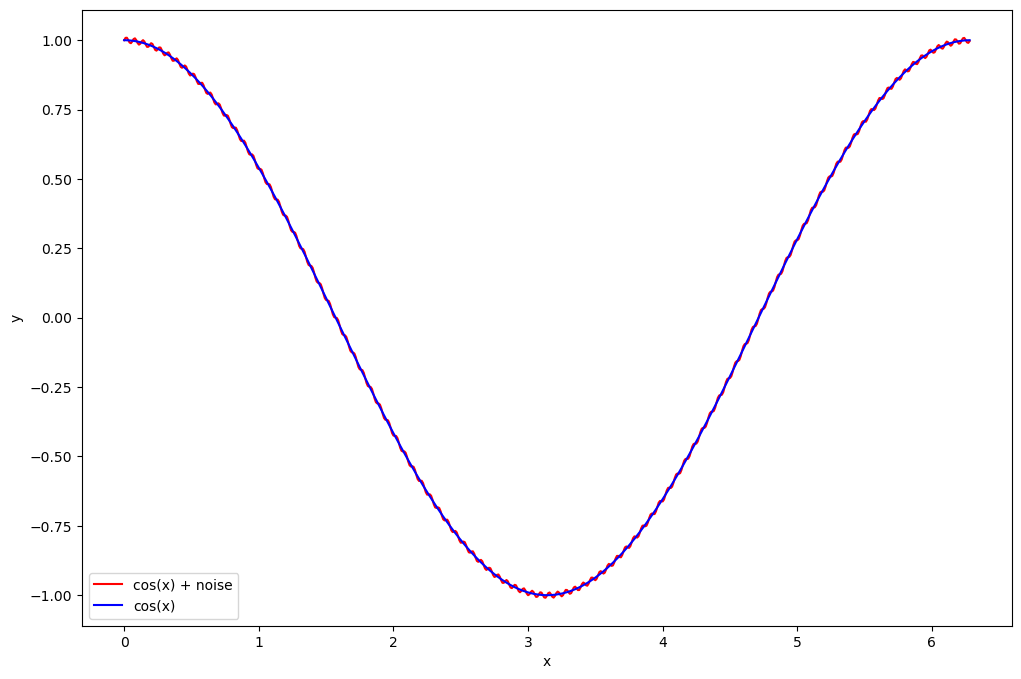

In [ ]:
x = np.arange(0, 2*np.pi, 0.01) 
# compute function
omega = 100
epsilon = 0.01

y = np.cos(x) 
y_noise = y + epsilon*np.sin(omega*x)

# Plot solution
plt.figure(figsize = (12, 8))
plt.plot(x, y_noise, 'r-', \
         label = 'cos(x) + noise')
plt.plot(x, y, 'b-', \
         label = 'cos(x)')

plt.xlabel('x')
plt.ylabel('y')

plt.legend()
plt.show()

The derivatives of our two test functions are

$$\large f^{\prime}(x) = -\sin(x)$$

and

$$\large f_{\epsilon,\omega}^{\prime}(x) = -\sin(x)+\epsilon\omega \cos(\omega x).$$



Since $\epsilon\omega$ may not be small when $\omega$ is large, the contribution of the noise to the derivative may not be small. As a result, the derivative (analytic and numerical) may not be usable. For instance, the following figure shows $f^{\prime}(x)$ and $f^{\prime}_{\epsilon,\omega}(x)$ for $\epsilon = 0.01$ and $\omega = 100$.

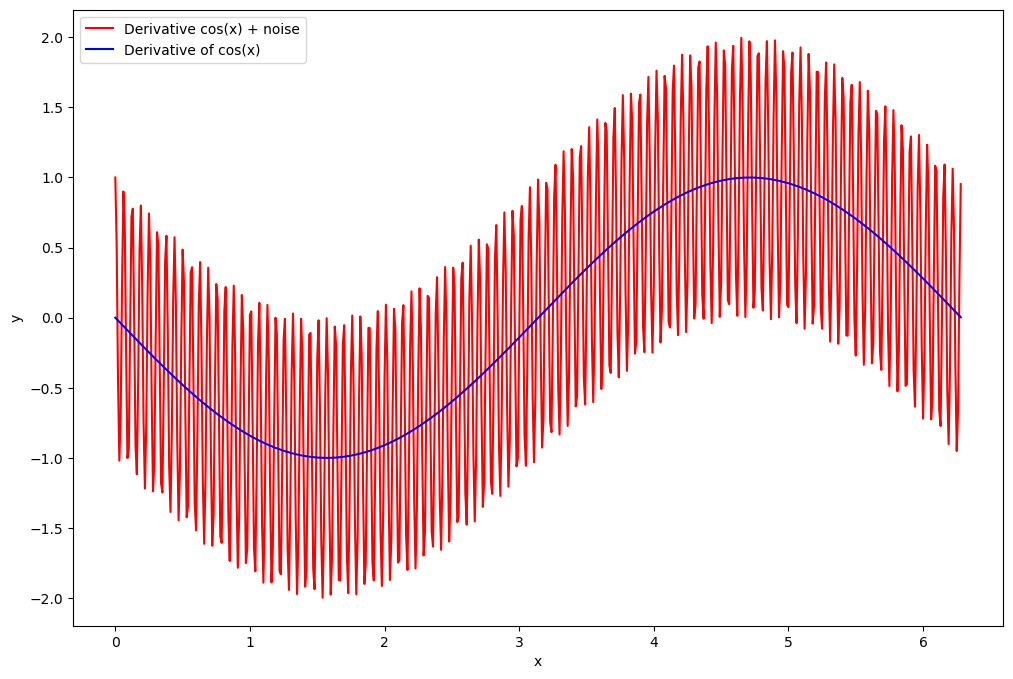

In [ ]:
x = np.arange(0, 2*np.pi, 0.01) 
# compute function
y = -np.sin(x) 
y_noise = y + epsilon*omega*np.cos(omega*x)

# Plot solution
plt.figure(figsize = (12, 8))
plt.plot(x, y_noise, 'r-', \
         label = 'Derivative cos(x) + noise')
plt.plot(x, y, 'b-', \
         label = 'Derivative of cos(x)')

plt.xlabel('x')
plt.ylabel('y')

plt.legend()
plt.show()

## Some possible solutions

* Fit a smooth curve for the noisy points.
* The smooth curve can be piece-wise.
* Or, use filters to remove the noise.
    - Moving average (bad idea because it shifts the curve)
    - Kalman filter
    - IIR (infinite impulse response) filter
    - FIR (finite impulse response) filter
    - Savitzky-Golay filter
    
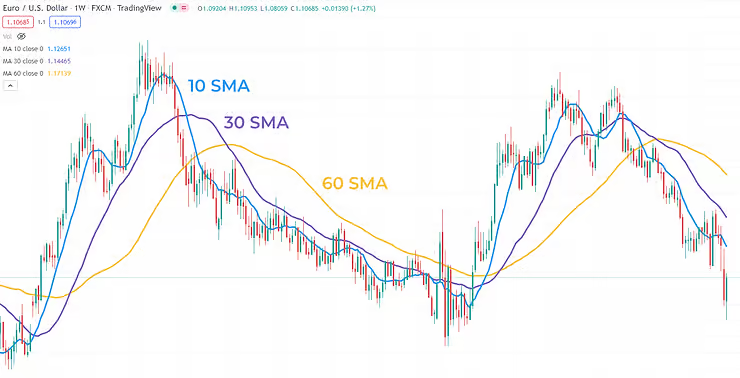

## Smoothing noisy data with Savitzky-Golay Filter in Python



<img src="https://upload.wikimedia.org/wikipedia/commons/8/89/Lissage_sg3_anim.gif" width="750" align="center">

* A Savitzky–Golay filter is a digital filter that can be applied to a set of digital data points for the purpose of smoothing the data
* It increases the precision of the data without distorting the signal tendency. 
* This is achieved, in a process known as convolution, by fitting successive sub-sets of adjacent data points with a low-degree polynomial by the method of linear least squares. 
* https://github.com/scipy/scipy/blob/v1.11.3/scipy/signal/_savitzky_golay.py#L230-L357

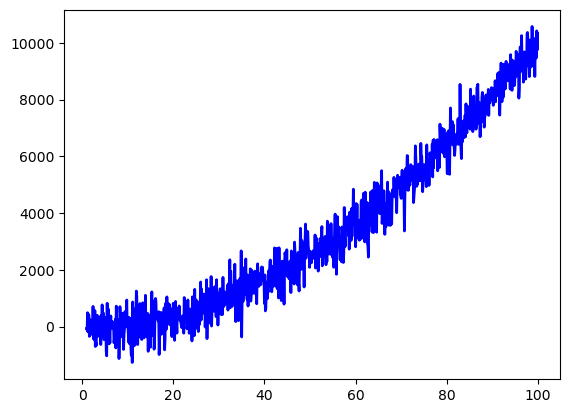

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 500
x = np.arange(1, 100, 0.1)  # x axis
z = np.random.normal(mu, sigma, len(x))  # noise
y = x ** 2 + z # data
plt.plot(x, y, linewidth=2, linestyle="-", c="b")  # it include some noise

### Apply the Savitzky-Golay filter


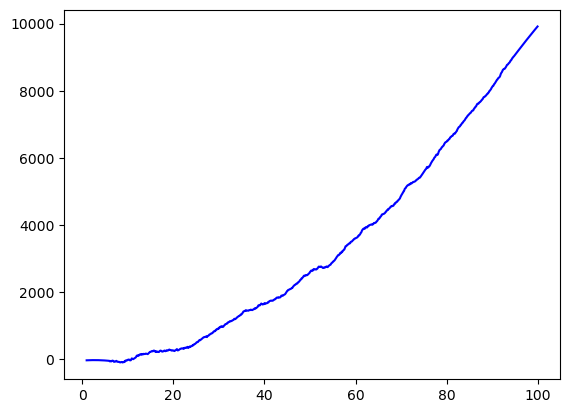

In [ ]:
from scipy.signal import savgol_filter
w = savgol_filter(y, 101, 2)
plt.plot(x, w, 'b')  # high frequency noise removed

### Increasing the window_length to 500:

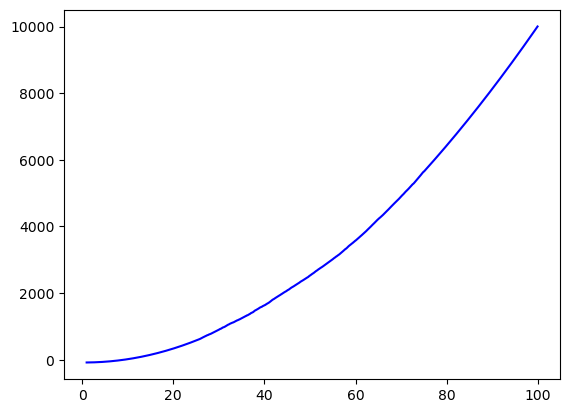

In [ ]:
w = savgol_filter(y, 500, 2)
plt.plot(x, w, 'b')  # high frequency noise removed

### Let's apply Savitzky-Golay filter on Numerical Differentiation

In [ ]:
x = np.arange(0, 2*np.pi, 0.01) 
# compute function
omega = 100
epsilon = 0.01

y = np.cos(x) 
y_noise = y + epsilon*np.sin(omega*x)
y_noise

array([ 1.00000000e+00,  1.00836471e+00,  1.00889298e+00,  1.00096123e+00,
        9.91632082e-01,  9.89161018e-01,  9.95406385e-01,  1.00412087e+00,
        1.00669529e+00,  1.00007392e+00,  9.89563954e-01,  9.83956196e-01,
        9.87442907e-01,  9.95763564e-01,  1.00012207e+00,  9.95273956e-01,
        9.84348250e-01,  9.75970792e-01,  9.76333820e-01,  9.83503007e-01,
        9.89196030e-01,  9.86397471e-01,  9.75808936e-01,  9.65204191e-01,
        9.62282191e-01,  9.67588904e-01,  9.74015563e-01,  9.73334656e-01,
        9.63764496e-01,  9.51607537e-01,  9.45456173e-01,  9.48293193e-01,
        9.54749685e-01,  9.56041462e-01,  9.48045492e-01,  9.35090886e-01,
        9.25979035e-01,  9.25891964e-01,  9.31628321e-01,  9.34547014e-01,
        9.28512126e-01,  9.15534596e-01,  9.03923725e-01,  9.00648002e-01,
        9.04928682e-01,  9.08956138e-01,  9.05070381e-01,  8.92804019e-01,
        8.79312376e-01,  8.72795332e-01,  8.74958813e-01,  8.79446799e-01,
        8.77685456e-01,  

In [ ]:
import numpy as np
from scipy import signal

In [ ]:
y_smooth = signal.savgol_filter(y_noise, window_length=11, polyorder=3, mode="nearest")
y_smooth

array([ 1.00390079e+00,  1.00293106e+00,  1.00077123e+00,  9.98957736e-01,
        9.98436230e-01,  9.98682415e-01,  9.98180750e-01,  9.97597433e-01,
        9.96871645e-01,  9.95981848e-01,  9.94965662e-01,  9.93885348e-01,
        9.92770659e-01,  9.91591579e-01,  9.90286023e-01,  9.88817037e-01,
        9.87206893e-01,  9.85516747e-01,  9.83790553e-01,  9.82014805e-01,
        9.80131113e-01,  9.78090054e-01,  9.75896794e-01,  9.73606520e-01,
        9.71273903e-01,  9.68903033e-01,  9.66443878e-01,  9.63838503e-01,
        9.61074568e-01,  9.58196914e-01,  9.55266586e-01,  9.52304967e-01,
        9.49274387e-01,  9.46113030e-01,  9.42792054e-01,  9.39342403e-01,
        9.35826656e-01,  9.32281806e-01,  9.28685567e-01,  9.24977192e-01,
        9.21113661e-01,  9.17109577e-01,  9.13024096e-01,  9.08906899e-01,
        9.04752888e-01,  9.00507252e-01,  8.96116246e-01,  8.91577001e-01,
        8.86940565e-01,  8.82265382e-01,  8.77563980e-01,  8.72791881e-01,
        8.67888929e-01,  

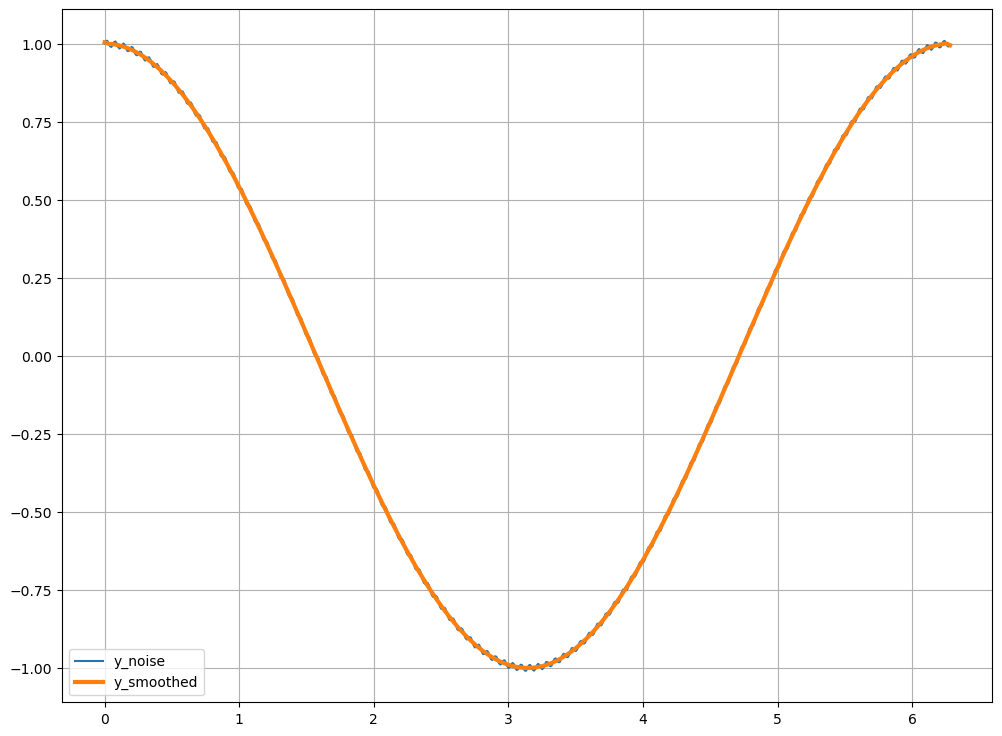

In [ ]:
plt.figure(figsize=(12, 9))
plt.plot(x, y_noise, label="y_noise")
plt.plot(x, y_smooth, linewidth=3, label="y_smoothed")
plt.legend()
plt.grid(True)
plt.show() 

In [ ]:
import plotly.express as px
import pandas as pd
df=pd.DataFrame({"x":x, "y_smooth":y_smooth, "y_noise": y_noise})
df

,x,y_smooth,y_noise
0,0.00,1.003901,1.000000
1,0.01,1.002931,1.008365
2,0.02,1.000771,1.008893
3,0.03,0.998958,1.000961
4,0.04,0.998436,0.991632
...,...,...,...
624,6.24,0.999923,1.008302
625,6.25,1.000350,1.001210
626,6.26,0.999048,0.992399
627,6.27,0.996628,0.990230


In [ ]:
fig = px.line(df, x="x", y="y_noise")

fig.show()

In [ ]:
fig = px.line(df, x="x", y="y_noise")
fig.add_scatter(x=df['x'], y=df['y_smooth'], mode='lines', hovertext=df['y_smooth'], hoverinfo="text",)
fig.show()

In [ ]:
x = np.arange(0, 2*np.pi, 0.01) 
# compute function
y = -np.sin(x) 
y_noise = y + epsilon*omega*np.cos(omega*x)

forward_diff = np.diff(y_smooth)/0.01

forward_diff

array([-0.09697252, -0.21598283, -0.18134981, -0.0521506 ,  0.02461848,
       -0.0501665 , -0.05833166, -0.07257883, -0.08897961, -0.10161866,
       -0.10803138, -0.11146888, -0.11790807, -0.13055555, -0.14689859,
       -0.16101441, -0.16901465, -0.17261937, -0.17757478, -0.18836924,
       -0.20410583, -0.21932602, -0.22902737, -0.23326179, -0.23708699,
       -0.24591547, -0.26053748, -0.2763935 , -0.28776541, -0.2930328 ,
       -0.29616186, -0.30305805, -0.31613572, -0.33209753, -0.34496511,
       -0.3515747 , -0.35448501, -0.3596239 , -0.37083747, -0.38635311,
       -0.4004084 , -0.40854816, -0.41171972, -0.41540107, -0.42456361,
       -0.43910061, -0.45392452, -0.4636436 , -0.46751826, -0.47014018,
       -0.47720996, -0.49029519, -0.5053884 , -0.51659071, -0.52153446,
       -0.52355919, -0.52864053, -0.53989543, -0.55471568, -0.56716511,
       -0.57343651, -0.57535118, -0.57868372, -0.58785208, -0.60185501,
       -0.61519186, -0.62291908, -0.6251946 , -0.62713191, -0.63

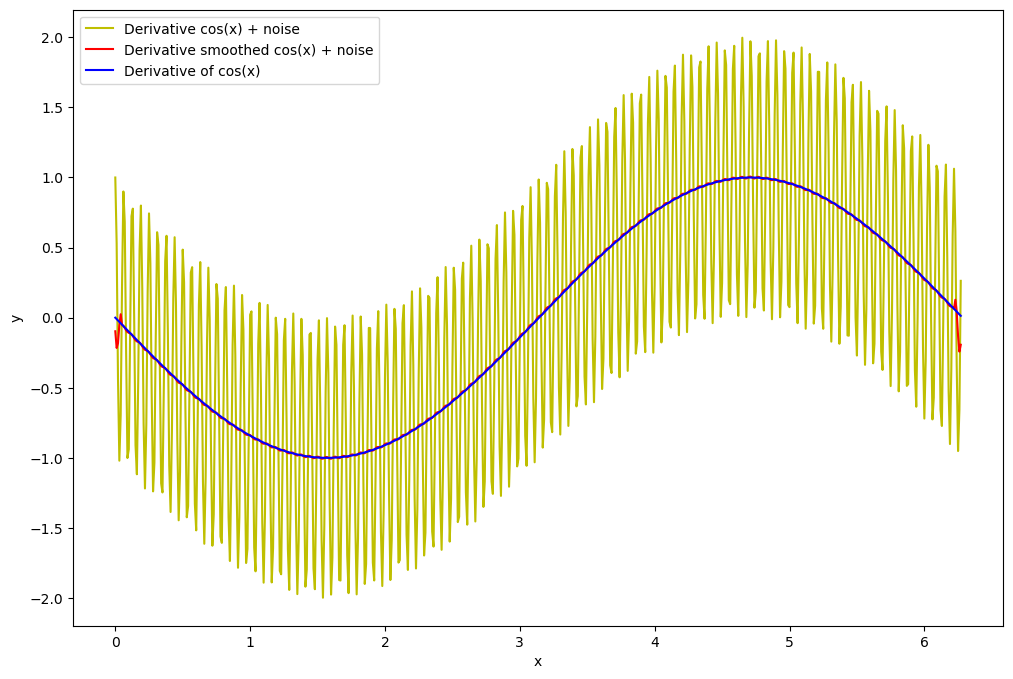

In [ ]:
# Plot solution
plt.figure(figsize = (12, 8))
plt.plot(x[:-1], y_noise[:-1], 'y-', \
         label = 'Derivative cos(x) + noise')
plt.plot(x[:-1:], forward_diff, 'r-', \
         label = 'Derivative smoothed cos(x) + noise')
plt.plot(x[:-1], y[:-1], 'b-', \
         label = 'Derivative of cos(x)')

plt.xlabel('x')
plt.ylabel('y')

plt.legend()
plt.show()

In [ ]:
df=pd.DataFrame({"x":x[:-1], "y_smooth_diff":forward_diff, "y_noise_diff": y_noise[:-1], "y_analytic_diff": y[:-1]})
df

,x,y_smooth_diff,y_noise_diff,y_analytic_diff
0,0.00,-0.096973,1.000000,-0.000000
1,0.01,-0.215983,0.530302,-0.010000
2,0.02,-0.181350,-0.436146,-0.019999
3,0.03,-0.052151,-1.019988,-0.029996
4,0.04,0.024618,-0.693633,-0.039989
...,...,...,...,...
623,6.23,0.127874,0.622861,0.053160
624,6.24,0.042692,-0.340582,0.043172
625,6.25,-0.130148,-0.951208,0.033179
626,6.26,-0.242067,-0.656796,0.023183


In [ ]:
fig = px.line(df, x="x", y="y_noise_diff")
fig.add_scatter(x=df['x'], y=df['y_smooth_diff'], mode='lines', hovertext=df['y_smooth_diff'], hoverinfo="text",)
fig.add_scatter(x=df['x'], y=df['y_analytic_diff'], mode='lines', hovertext=df['y_analytic_diff'], hoverinfo="text",)
fig.show()

## Derivatives by Interpolation

* If f (x) is given as a set of discrete data points, interpolation can be a very effective means of computing its derivatives. 
* The idea is to approximate the derivative of $f (x)$ by the derivative of the interpolant. 
* This method is particularly useful if the data points are located at uneven intervals of x, when the finite difference approximations are not applicable.

## Summary of Numerical Differentiation


1. Because explicit derivation of functions is sometimes cumbersome, numerical approaches can be preferable.
2. Numerical approximation of derivatives can be done using a grid on which the derivative is approximated by finite differences.
3. Finite differences approximate the derivative by ratios of differences in the function value over small intervals.
4. Finite difference schemes have different approximation orders depending on the method used.
5. There are issues with finite differences for approximation of derivatives when the data is noisy.

# Integration Algorithms

* The integral of a function is normally described as the "area under the curve." 

* The integral has many applications for modeling, predicting, and understanding dynamic systems. 

* However, finding an exact solution for the integral of a function is difficult or impossible.

* This class describes several methods of numerically integrating functions and their geometric interpretation as well as their accuracy analysis.


## Numerical Integration Problem Statement

* Given a function $f(x)$, we want to approximate the integral of $f(x)$ over the total **interval**, $[a,b]$. 

* The following figure illustrates this area.

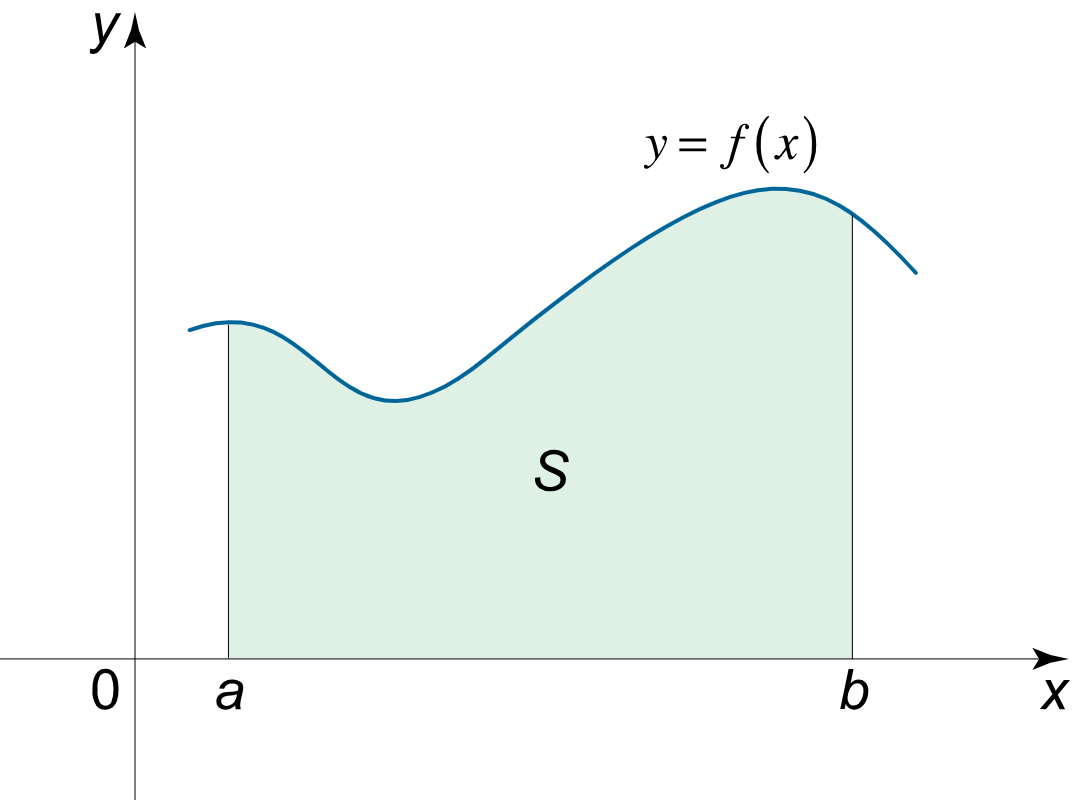

* To accomplish this goal, we assume that the interval has been discretized into a numeral grid, $x$, consisting of $n+1$ points with spacing, $h = \frac{b - a}{n}$. 
* Here, we denote each point in $x$ by $x_i$, where $x_0 = a$ and $x_n = b$. 

$$\large a = {x_0} \lt {x_1} \lt {x_2} \lt \cdots \lt {x_i} \lt \cdots \lt {x_n} = b.$$

* Note: There are $n+1$ grid points because the count starts at $x_0$. We also assume we have a function, $f(x)$, that can be computed for any of the grid points, or that we have been given the function implicitly as $f(x_i)$. 

* The interval $[x_i, x_{i+1}]$ is referred to as a **subinterval**. Then the subintervals are

$$\large \left[ {{x_0},{x_1}} \right],\left[ {{x_1},{x_2}} \right], \ldots , \left[ {{x_{n - 1}},{x_n}} \right]. $$


### THE MEAN VALUE THEOREM FOR INTEGRALS

If $f
(
x
)$
 is continuous over an interval 
 $
[
a
,
b
]$
,
 then there is at least one point 
 $
\xi
∈
[
a
,
b
]$
 such that
 
 $$\large f(\xi)=\frac{1}{b-a}{\displaystyle\int }_{a}^{b}f(x)dx. $$
 
 
This formula can also be stated as

$$\large {\displaystyle\int }_{a}^{b}f(x)dx=f(\xi)(b-a).$$

### How to numerically integrate a function?

* Some most common methods of approximating $\int_a^b f(x) dx$. 
* Apparently it is hard to find such $\xi$ in any range of $[
a
,
b
]$
* Alternatively, if we can make $a$ and $b$ close enough, we don't have to know the exact $\xi$, and the error is in control. 
* Each method approximates the area under $f(x)$ for each subinterval by a shape for which it is easy to compute the exact area, and then sums the area contributions of every subinterval.

## Riemanns Integral



* The simplest method for approximating integrals is by summing the area of rectangles that are defined for each subinterval. 
* The width of the rectangle is $x_{i+1} - x_i = h$, and the height is defined by a function value $f(x)$ for some $x={\xi _i}$ in the subinterval. 
* An obvious choice for the height is the function value at the left endpoint, $x_i$, or the right endpoint, $x_{i+1}$, because these values can be used even if the function itself is not known. 

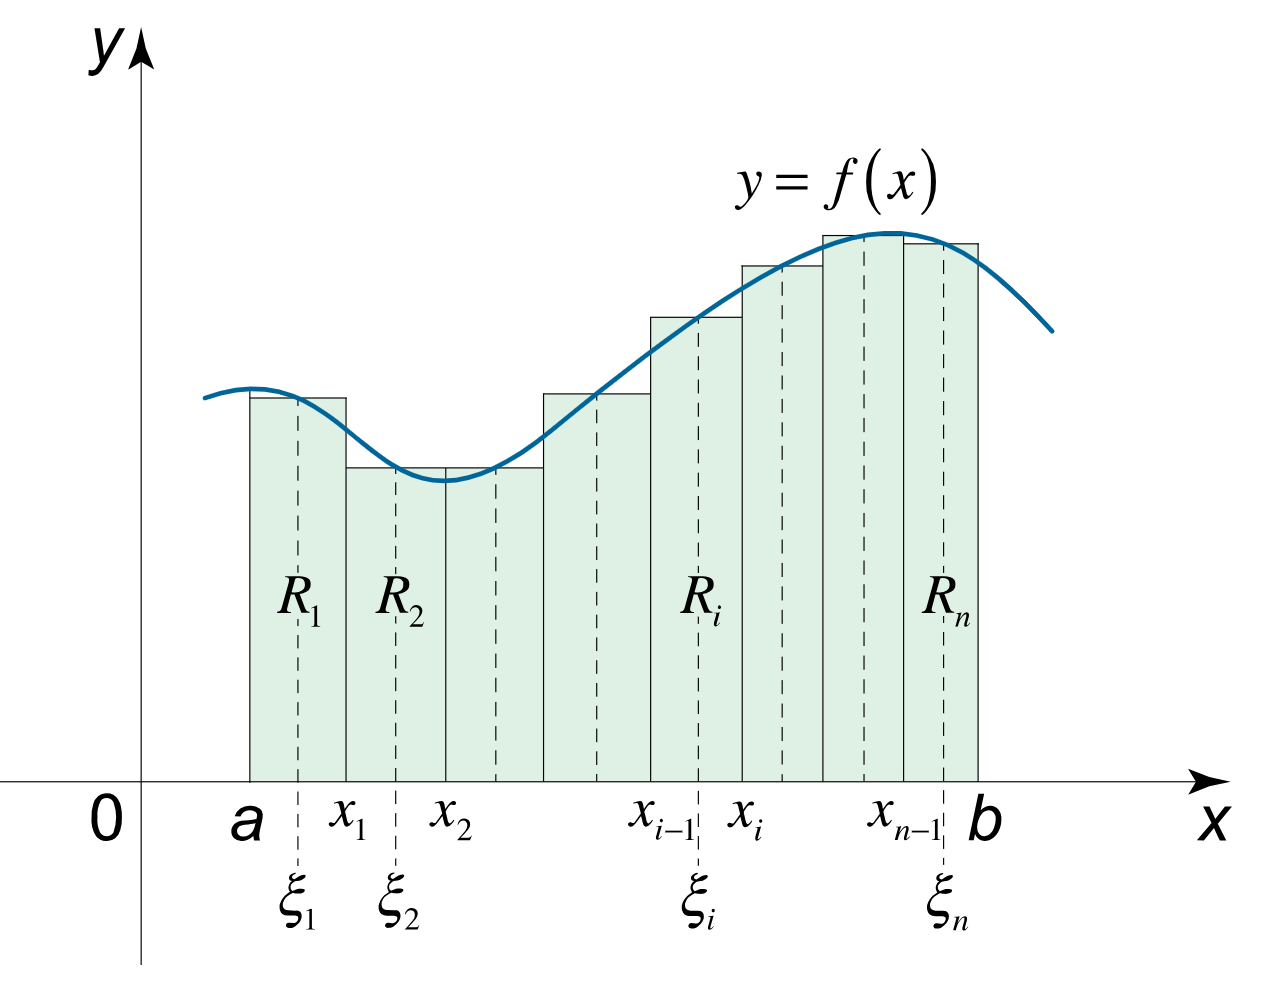

* A left Riemann sum underestimates an increasing function and overestimates a decreasing function.

* A right Riemann sum overestimates an increasing function and underestimates a decreasing function.

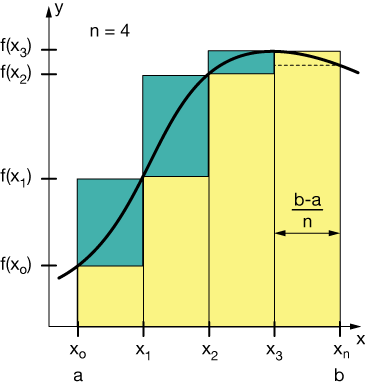

* If $n$ is large enough, then the result is getting more accurate.

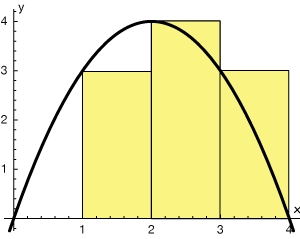
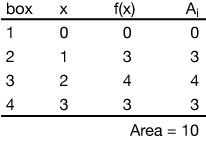

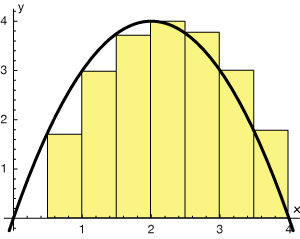
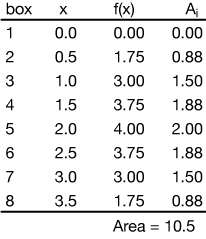

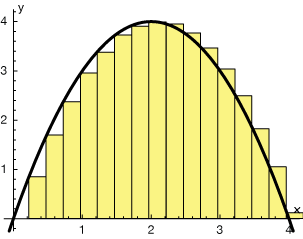
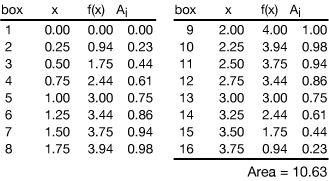

## Accuracy Analysis


This method gives the **Riemann Integral** approximation, which is

$$\large \int_a^b f(x) dx \approx \sum_{i = 0}^{n-1} hf(x_i),$$

or

$$\large \int_a^b f(x) dx \approx \sum_{i = 1}^{n} hf(x_i),$$

depending on whether the left or right endpoint is chosen.

Rewrite the integral of $f(x)$ over an arbitrary subinterval in terms of the Taylor series. The Taylor series of $f(x)$ around $a = x_i$ is

$$\large f(x) = f(x_i) + f^{\prime}(x_i)(x-x_i) + \cdots$$

Thus

$$\large \int_{x_i}^{x_{i+1}} f(x) dx = \int_{x_i}^{x_{i+1}} (f(x_i) + f^{\prime}(x_i)(x-x_i) + \cdots)\ dx$$

by substitution of the Taylor series for the function. Since the integral distributes, we can rearrange the right side into the following form:

$$\large \int_{x_i}^{x_{i+1}} f(x_i) dx + \int_{x_i}^{x_{i+1}} f^{\prime}(x_i)(x-x_i)dx + \cdots.\$$

Solving each integral separately results in the approximation

$$\large \int_{x_i}^{x_{i+1}} f(x) dx = hf(x_i) + \frac{h^2}{2}f^{\prime}(x_i) + O(h^3),$$

which is just

$$\large \int_{x_i}^{x_{i+1}} f(x) dx = hf(x_i) + O(h^2).$$

Since the $hf(x_i)$ term is our Riemann integral approximation for a single subinterval, the Riemann integral approximation over a single interval is $O(h^2)$.

If we sum the $O(h^2)$ error over the entire Riemann sum, we get $nO(h^2)$. The relationship between $n$ and $h$ is

$$\large h = \frac{b - a}{n},$$

and so our total error becomes $\frac{b - a}{h}O(h^2) = O(h)$ over the whole interval. 

### Thus the overall accuracy is $O(h)$.

## Midpoint Rule

* The **Midpoint Rule** takes the rectangle height of the rectangle at each subinterval to be the function value at the midpoint between $x_i$ and $x_{i+1}$, which for compactness we denote by $\large y_i = \frac{x_{i+1} + x_i}{2}$. 
* Intuitively, $y_i$ should be closer to $\xi$ in the mean value theorem than the left endpoint or right endpoint. So the accuracy SHOULD be better. Let's check it.



$$\large \int_a^b f(x)dx \approx \sum_{i = 0}^{n-1} hf(y_i).$$

Similarly to the Riemann integral, we take the Taylor series of $f(x)$ around $y_i$, which is

$$\large f(x) = f(y_i) + f^{\prime}(y_i)(x - y_i) + \frac{f''(y_i)(x - y_i)^2}{2!} + \cdots$$

Then the integral over a subinterval is

$$\large \int_{x_i}^{x_{i+1}} f(x) dx= \int_{x_i}^{x_{i+1}} \left(f(y_i) + f^{\prime}(y_i)(x - y_i) + \frac{f''(y_i)(x - y_i)^2}{2!} + \cdots\right) dx,$$

which distributes to

$$\large \int_{x_i}^{x_{i+1}} f(x) dx= \int_{x_i}^{x_{i+1}} f(y_i)dx + \int_{x_i}^{x_{i+1}} f^{\prime}(y_i)(x - y_i)dx + \int_{x_i}^{x_{i+1}} \frac{f''(y_i)(x - y_i)^2}{2!}dx + \cdots.$$


Recognizing that since $x_i$ and $x_{i+1}$ are symmetric around $y_i$, then $\int_{x_i}^{x_{i+1}} f^{\prime}(y_i)(x - y_i)dx = 0$. This is true for the integral of $(x - y_i)^p$ for any odd $p$. For the integral of $(x - y_i)^p$ and with $p$ even, it suffices to say that $\int_{x_i}^{x_{i+1}} (x - y_i)^p dx = \int_{-\frac{h}{2}}^{\frac{h}{2}} x^p dx$, which will result in some multiple of $h^{p+1}$ with no lower order powers of $h$.


Utilizing these facts reduces the expression for the integral of $f(x)$ to

$$\large \int_{x_i}^{x_{i+1}} f(x) dx= hf(y_i) + O(h^3).$$

### Midpoint rule has overall accuracy $O(h^2)$

* Since $hf(y_i)$ is the approximation of the integral over the subinterval, the Midpoint Rule is $O(h^3)$ for one subinterval, and using similar arguments as for the Riemann Integral, **is $O(h^2)$ over the whole interval.**
* Since the Midpoint Rule requires the same number of calculations as the Riemann Integral, we essentially get an extra order of accuracy for free! 
* However, if $f(x_i)$ is given in the form of data points, then we will not be able to compute $f(y_i)$ for this integration scheme.

## Example

Use the left Riemann Integral, right Riemann Integral, and Midpoint Rule to approximate $\large \int_{0}^{\pi} \text{sin}(x) dx$ wtih 11 evenly spaced grid ponts over the whole interval. Compare this value to the exact value of 2.

In [ ]:
import numpy as np

a = 0
b = np.pi
n = 11
h = (b - a) / (n - 1)
x = np.linspace(a, b, n)
f = np.sin(x)

I_riemannL = h * sum(f[:n-1])
err_riemannL = 2 - I_riemannL

I_riemannR = h * sum(f[1::])
err_riemannR = 2 - I_riemannR

I_mid = h * sum(np.sin((x[:n-1] + x[1:])/2))
err_mid = 2 - I_mid

print(I_riemannL)
print(err_riemannL)

print(I_riemannR)
print(err_riemannR)

print(I_mid)
print(err_mid)

1.9835235375094546
0.01647646249054535
1.9835235375094546
0.01647646249054535
2.0082484079079745
-0.008248407907974542


## Trapezoid Rule

* The **Trapezoid Rule** fits a trapezoid into each subinterval and sums the areas of the trapezoid to approximate the total integral. 
* This approximation for the integral to an arbitrary function is shown in the following figure. 
* For each subinterval, the Trapezoid Rule computes the area of a trapezoid with corners at $(x_i, 0), (x_{i+1}, 0), (x_i, f(x_i))$, and $(x_{i+1}, f(x_{i+1}))$, which is $\large h\frac{f(x_i) + f(x_{i+1})}{2}$. 
* Thus, the Trapezoid Rule approximates integrals according to the expression

$$\large \int_a^b f(x) dx \approx \sum_{i=0}^{n-1} h\frac{f(x_i) + f(x_{i+1})}{2}.$$

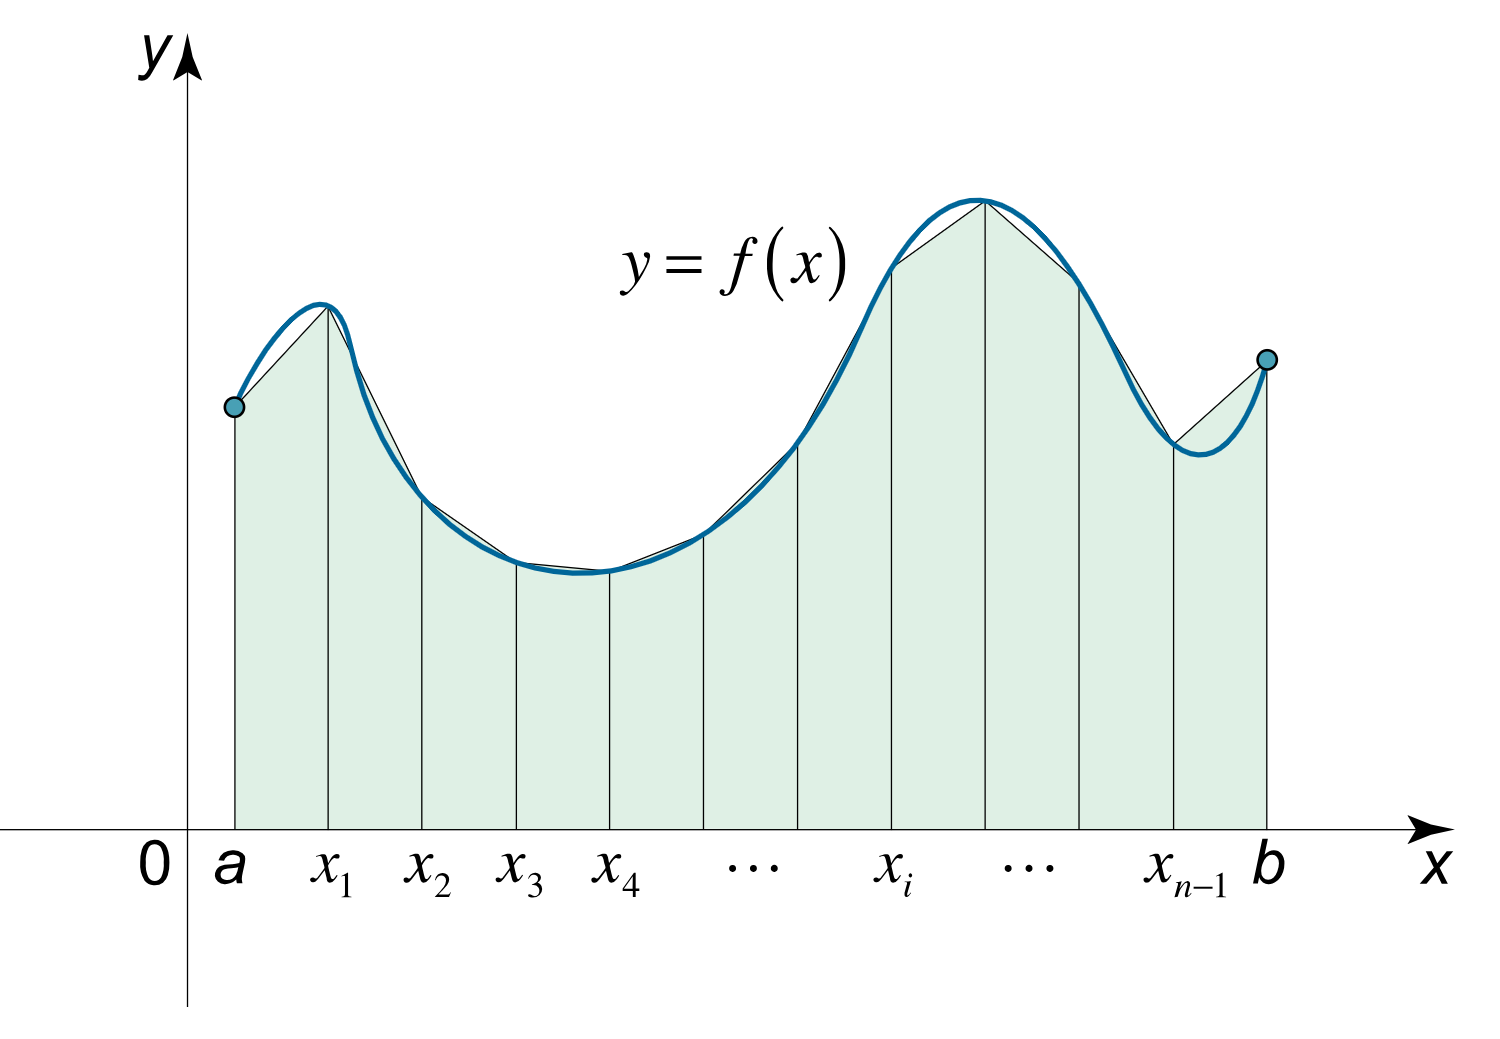

### Avoid double counts in computation

* You may notice that the Trapezoid Rule "double-counts" most of the terms in the series. 

$$\large \begin{eqnarray*}\sum_{i=0}^{n-1} h\frac{f(x_i) + f(x_{i+1})}{2} &=& \frac{h}{2} \left[(f(x_0) + f(x_1)) + (f(x_1) + f(x_2)) + (f(x_2)\right. \\
&&\left. + f(x_3)) + \cdots + (f(x_{n-1}) + f(x_n))\right].\end{eqnarray*}$$

* Computationally, we can be more efficient using the following expression.

$$\large \int_a^b f(x) dx \approx \frac{h}{2} \left(f(x_0) + 2 \left(\sum_{i=1}^{n-1} f(x_i)\right) + f(x_n)\right).$$

## Accuracy analysis

To determine the accuracy of the Trapezoid Rule approximation, we first take Taylor series expansion of $f(x)$ around $\large y_i = \frac{x_{i+1} + x_i}{2}$, which is the midpoint between $x_i$ and $x_{i+1}$. This Taylor series expansion is

$$\large f(x) = f(y_i) + f^{\prime}(y_i)(x - y_i) + \frac{f''(y_i)(x - y_i)^2}{2!} + \cdots$$

Computing the Taylor series at $x_i$ and $x_{i+1}$ and noting that $x_i - y_i = -\frac{h}{2}$ and $x_{i+1} - y_i = \frac{h}{2}$, results in the following expressions:

$$\large f(x_i) = f(y_i) - \frac{hf^{\prime}(y_i)}{2} + \frac{h^2f''(y_i)}{8} - \cdots$$

and

$$\large f(x_{i+1}) = f(y_i) + \frac{hf^{\prime}(y_i)}{2} + \frac{h^2f''(y_i)}{8} + \cdots.$$

Taking the average of these two expressions results in the new expression,

$$\large \frac{f(x_{i+1})+f(x_i)}{2} = f(y_i) + O(h^2).$$

Solving this expression for $f(y_i)$ yields

$$\large f(y_i) = \frac{f(x_{i+1})+f(x_i)}{2} + O(h^2).$$

Now returning to the Taylor expansion for $f(x)$, the integral of $f(x)$ over a subinterval is

$$\large \int_{x_i}^{x_{i+1}} f(x) dx = \int_{x_i}^{x_{i+1}} \left(f(y_i) + f^{\prime}(y_i)(x - y_i) + \frac{f''(y_i)(x - y_i)^2}{2!} + \cdots\right) dx.$$

Distributing the integral results in the expression

$$\large \int_{x_i}^{x_{i+1}} f(x) dx = \int_{x_i}^{x_{i+1}} f(y_i) dx + \int_{x_i}^{x_{i+1}} f^{\prime}(y_i)(x - y_i)dx + \int_{x_i}^{x_{i+1}} \frac{f''(y_i)(x - y_i)^2}{2!} dx + \cdots$$

Now since $x_i$ and $x_{i+1}$ are symmetric around $y_i$, the integrals of the odd powers of $(x - y_i)^p$ disappear and the even powers resolve to a multiple $h^{p+1}$.

$$\large \int_{x_i}^{x_{i+1}} f(x) dx = hf(y_i) + O(h^3).$$

Now if we substitute $f(y_i)$ with the expression derived explicitly in terms of $f(x_i)$ and $f(x_{i+1})$, we get

$$\large \int_{x_i}^{x_{i+1}} f(x) dx = h \left(\frac{f(x_{i+1})+f(x_i)}{2} + O(h^2)\right) + O(h^3), $$

which is equivalent to

$$\large h \left(\frac{f(x_{i+1})+f(x_i)}{2}\right) + hO(h^2) + O(h^3)$$

and therefore,

$$\large \int_{x_i}^{x_{i+1}} f(x) dx = h \left(\frac{f(x_{i+1})+f(x_i)}{2}\right) + O(h^3).$$

### Since $\frac{h}{2}(f(x_{i+1}) + f(x_i))$ is the Trapezoid Rule approximation for the integral over the subinterval, it is $O(h^3)$ for a single subinterval and $O(h^2)$ over the whole interval.

## Question

Since the accuracy and computational cost are same as midpoint rule, then which one to choose? 

Midpoint is actually a little more accurate than trapezoid rule.

On an interval where a function is concave-down, the Trapezoidal Rule will consistently underestimate the area under the curve. (And inversely, if the function is concave up, the Trapezoidal Rule will consistently overestimate the area.)

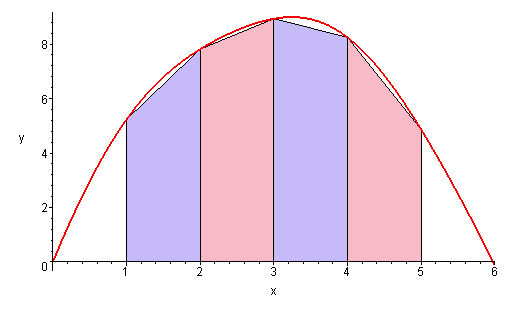

With the Midpoint Rule, each rectangle will sometimes overestimate and sometimes underestimate the function (unless the function has a local minimum/maximum at the midpoint), and so the errors partially cancel out. (They exactly cancel out if the function is a straight line.)

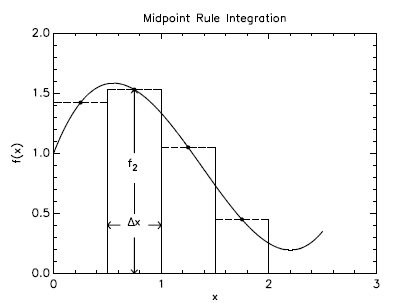

## Example

Use the Trapezoid Rule to approximate $\int_0^{\pi} \sin(x) dx$ with 11 evenly spaced grid points over
the whole interval. Compare this value to the exact value of 2.

In [ ]:
import numpy as np

a = 0
b = np.pi
n = 11
h = (b - a) / (n - 1)
x = np.linspace(a, b, n)
f = np.sin(x)

I_trap = (h/2)*(f[0] + \
          2 * sum(f[1:n-1]) + f[n-1])
err_trap = 2 - I_trap

print(I_trap)
print(err_trap)

1.9835235375094546
0.01647646249054535


## Simpson's Rule

Consider *two* consecutive subintervals, $[x_{i-1}, x_i]$ and $[x_i, x_{i+1}]$. **Simpson's Rule** approximates the area under $f(x)$ over these two subintervals by fitting a quadratic polynomial through the points $(x_{i-1}, f(x_{i-1})), (x_i, f(x_i))$, and $(x_{i+1}, f(x_{i+1}))$, which is a unique polynomial, and then integrating the quadratic exactly. The following shows this integral approximation for an arbitrary function.

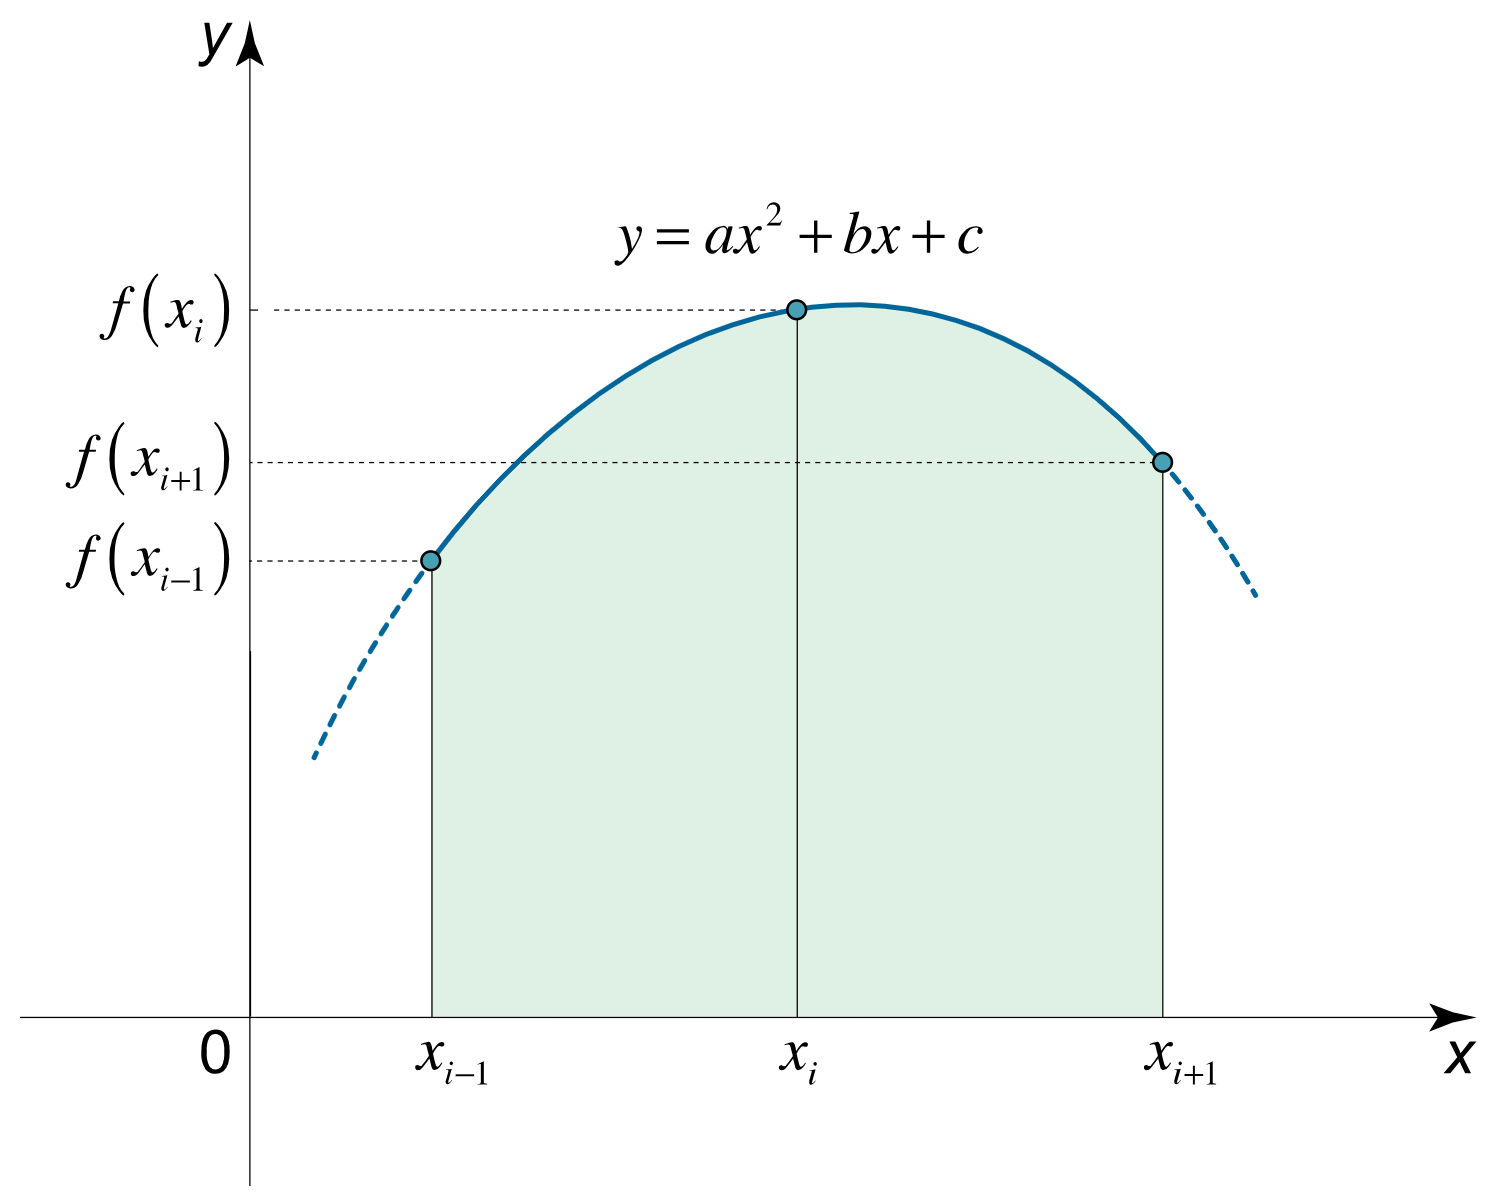

### How to construct the quadratic polynomial approximation of the function over the two subintervals?

The easiest way to do this is to use Lagrange polynomials. 

$$\large \begin{eqnarray*}P_i(x) &=& f(x_{i-1})\frac{(x - x_i)(x - x_{i+1})}{(x_{i-1} - x_i)(x_{i-1} - x_{i+1})} + f(x_i)\frac{(x - x_{i-1})(x - x_{i+1})}{(x_{i} - x_{i-1})(x_{i} - x_{i+1})}\\
&&+ f(x_{i+1})\frac{(x - x_{i-1})(x - x_{i})}{(x_{i+1} - x_{i-1})(x_{i+1} -
x_{i})},\end{eqnarray*}$$

and with substitutions for $h$ results in

$$\large P_i(x) = \frac{f(x_{i-1})}{2h^2} (x - x_i)(x - x_{i+1}) - \frac{f(x_i)}{h^2} (x - x_{i-1})(x - x_{i+1}) + \frac{f(x_{i+1})}{2h^2} (x - x_{i-1})(x - x_{i}).$$

You can confirm that the polynomial intersects the desired points. With some algebra and manipulation, the integral of $P_i(x)$ over the two subintervals is

$$\large \int_{x_{i-1}}^{x_{i+1}} P_i(x) dx = \frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1}))$$

### GREAT! We don't even need the polynomials at all.

To approximate the integral over $(a, b)$, we must sum the integrals of $P_i(x)$ over every *two* subintervals since $P_i(x)$ spans two subintervals. Substituting $\large \frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1}))$ for the integral of $P_i(x)$ and regrouping the terms for efficiency leads to the formula

$$\large \int_a^b f(x) dx \approx \frac{h}{3} \left[f(x_0)+4 \left(\sum_{i=1, i\  {\text{odd}}}^{n-1}f(x_i)\right)+2 \left(\sum_{i=2, i\  {\text{even}}}^{n-2}f(x_i)\right)+f(x_n)\right].$$

This regrouping is illustrated in the figure below:

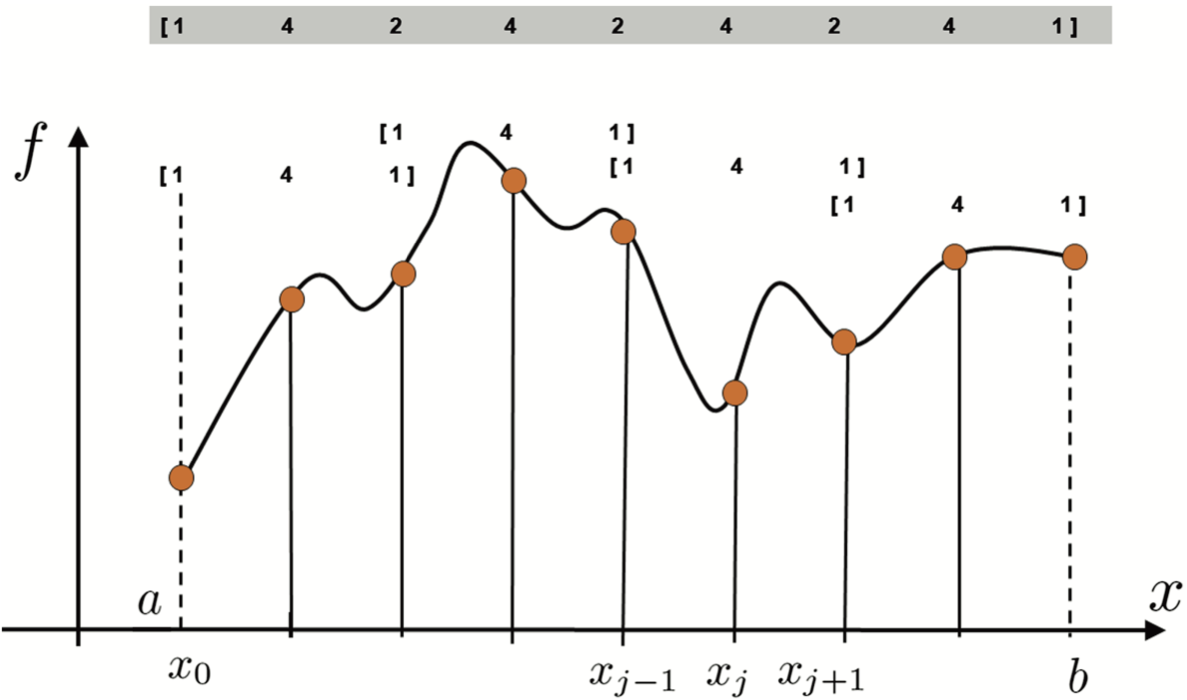

**There is a catch!** Note that to use Simpson's Rule, you **must** have an even number of intervals and, therefore, an odd number of grid points.

## Accuracy Analysis

Take the Taylor series approximation of $f(x)$ around $x_i$, which is

$$\large f(x) = f(x_i) + f^{\prime}(x_i)(x - x_i) + \frac{f''(x_i)(x-x_i)^2}{2!} + \frac{f'''(x_i)(x-x_i)^3}{3!} + \frac{f''''(x_i)(x-x_i)^4}{4!} + \cdots$$

Computing the Taylor series at $x_{i-1}$ and $x_{i+1}$ and substituting for $h$ where appropriate gives the expressions

$$\large f(x_{i-1}) = f(x_i) - hf^{\prime}(x_i) + \frac{h^2f''(x_i)}{2!} - \frac{h^3f'''(x_i)}{3!} + \frac{h^4f''''(x_i)}{4!} - \cdots$$

and

$$\large f(x_{i+1}) = f(x_i) + hf^{\prime}(x_i) + \frac{h^2f''(x_i)}{2!} + \frac{h^3f'''(x_i)}{3!} + \frac{h^4f''''(x_i)}{4!} + \cdots$$

Now consider the expression $\frac{f(x_{i-1}) + 4f(x_i) + f(x_{i+1})}{6}$. Substituting the Taylor series for the respective numerator values produces the equation

$$\large \frac{f(x_{i-1}) + 4f(x_i) + f(x_{i+1})}{6} = f(x_i) + \frac{h^2}{6}f''(x_i) + \frac{h^4}{72}f''''(x_i) + \cdots$$

Note that the odd terms cancel out. This implies

$$\large f(x_i) =\frac{f(x_{i-1}) + 4f(x_i) + f(x_{i+1})}{6} - \frac{h^2}{6}f''(x_i) + O(h^4).$$

By substitution of the Taylor series for $f(x)$, the integral of $f(x)$ over two subintervals is then

$$\large  \begin{eqnarray*}\int_{x_{i-1}}^{x_{i+1}} f(x) dx &=& \int_{x_{i-1}}^{x_{i+1}} \left(f(x_i) + f^{\prime}(x_i)(x - x_i) + \frac{f''(x_i)(x-x_i)^2}{2!}\right.\\
&&\qquad\qquad\left. + \frac{f'''(x_i)(x-x_i)^3}{3!}+ \frac{f''''(x_i)(x-x_i)^4}{4!} + \cdots\right)
dx.\end{eqnarray*}$$

Again, we distribute the integral and without showing it, we drop the integrals of terms with odd powers because they are zero.

$$\large \int_{x_{i-1}}^{x_{i+1}} f(x) dx = \int_{x_{i-1}}^{x_{i+1}} f(x_i) dx + \int_{x_{i-1}}^{x_{i+1}}\frac{f''(x_i)(x-x_i)^2}{2!}dx + \int_{x_{i-1}}^{x_{i+1}}\frac{f''''(x_i)(x-x_i)^4}{4!}dx + \cdots.$$

We then carry out the integrations. As will soon be clear, it benefits us to compute the integral of the second term exactly. The resulting equation is

$$\large \int_{x_{i-1}}^{x_{i+1}} f(x) dx = 2h f(x_i) + \frac{h^3}{3}f''(x_i) + O(h^5).$$

Substituting the expression for $f(x_i)$ derived earlier, the right-hand side becomes

$$\large 2h \left(\frac{f(x_{i-1}) + 4f(x_i) + f(x_{i+1})}{6} - \frac{h^2}{6}f''(x_i) + O(h^4)\right) + \frac{h^3}{3}f''(x_i) + O(h^5),$$

which can be rearranged to

$$\large \left[\frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1})) - \frac{h^3}{3}f''(x_i) + O(h^5)\right] + \frac{h^3}{3}f''(x_i) + O(h^5).$$

Canceling and combining the appropriate terms results in the integral expression

$$\large \int_{x_{i-1}}^{x_{i+1}} f(x) dx = \frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1})) + O(h^5).$$

### Recognizing that $\frac{h}{3}(f(x_{i-1}) + 4f(x_i) + f(x_{i+1}))$ is exactly the Simpson's Rule approximation for the integral over this subinterval, this equation implies that Simpson's Rule is $O(h^5)$ over a subinterval and $O(h^4)$ over the whole interval. 
- Because the $h^3$ terms cancel out exactly, Simpson's Rule gains another *two* orders of accuracy!

## Example

Use Simpson's Rule to approximate $\int_{0}^{\pi} \text{sin} (x)dx$ with 11 evenly spaced grid points over the whole interval. Compare this value to the exact value of 2.

In [ ]:
import numpy as np

a = 0
b = np.pi
n = 11
h = (b - a) / (n - 1)
x = np.linspace(a, b, n)
f = np.sin(x)

I_simp = (h/3) * (f[0] + 2*sum(f[:n-2:2]) \
            + 4*sum(f[1:n-1:2]) + f[n-1])
err_simp = 2 - I_simp

print(I_simp)
print(err_simp)

2.0001095173150043
-0.00010951731500430384


## Computing Integrals in Python

The `scipy.integrate` sub-package has several functions for computing integrals. The `trapz` takes as input arguments an array of function values $f$ computed on a numerical grid $x$.

### Example

Use the `trapz` function to approximate $\int_{0}^{\pi}\text{sin}(x)dx$ for 11 equally spaced points over the whole interval. Compare this value to the one computed in the early example using the Trapezoid Rule. 

In [ ]:
import numpy as np
from scipy.integrate import trapz

a = 0
b = np.pi
n = 11
h = (b - a) / (n - 1)
x = np.linspace(a, b, n)
f = np.sin(x)

I_trapz = trapz(f,x)
I_trap = (h/2)*(f[0] + 2 * sum(f[1:n-1]) + f[n-1])

print(I_trapz)
print(I_trap)

1.9835235375094544
1.9835235375094546


In [ ]:
from scipy.integrate import simpson
simpson(f, x)

2.0001095173150043

In [ ]:
f

array([0.00000000e+00, 3.09016994e-01, 5.87785252e-01, 8.09016994e-01,
       9.51056516e-01, 1.00000000e+00, 9.51056516e-01, 8.09016994e-01,
       5.87785252e-01, 3.09016994e-01, 1.22464680e-16])

In [ ]:
x

array([0.        , 0.31415927, 0.62831853, 0.9424778 , 1.25663706,
       1.57079633, 1.88495559, 2.19911486, 2.51327412, 2.82743339,
       3.14159265])

In [ ]:
import numpy as np
from scipy.integrate import quad

f=lambda x: 1/np.exp(x)
f(9)

quad(f, -9, np.inf)

C:\Users\damin\AppData\Local\Temp\ipykernel_5324\2777811677.py:4: RuntimeWarning: overflow encountered in exp
  f=lambda x: 1/np.exp(x)


(8103.083927575383, 4.734314314389348e-07)

# Homework of today

1. Compute $f'(x)$ and $f''(x) $ at $x = 0$ and $0.2$ using finite difference approximations

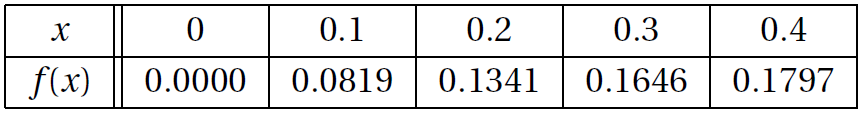

2. Use numerical methods to implement the European Call/Put price and Greeks.

    Requirements:

    1. Do not use the existing function to compute $N(x)$. You have to use numerical integration method.
    2. To compute all Greeks, only use the numerical differentiation. Do NOT use the analytic formula in the page.
    3. Your results should be close to the first two columns in Black Scholes Calculator. Please include screenshots and your results in your submission.

In [25]:
from IPython.display import IFrame
IFrame("https://www.macroption.com/black-scholes-formula/", 1000,500)

In [26]:
IFrame("https://www.math.drexel.edu/~pg/fin/VanillaCalculator.html", 1000,500)